# 02 — LGBM WFO v11: M1Y · Grid-Searched Execution · Long-Only · With Fees

**Architecture:**
- **Scheme:** M1Y (1-year sliding window) — empirically best Sharpe across v8
- **WFO:** ~103 monthly steps through full history; OOS 2024-01 → present
- **Features:** 11 features locked from v8 4-stage selection (no re-selection overhead)
- **Execution params:** full exhaustive grid search on validation window 2022-2023 (pre-OOS, never touches test)
- **Signal:** binary P(Up); **long-only** if P(Up) > `long_threshold`
- **Why long-only:** v10 proved that `P(Up) < threshold` is an impure short signal — binary label 0 conflates "down" with "flat". v10 shorts: 37.5% WR, avg_net = -0.0008. Shorts were a net drag.
- **Fees:** spot taker 0.05% for SL/timeout exits; 0% maker for limit entries and TP exits
- **Monthly analysis:** bar chart + 3-month SMA + calendar heatmap

In [1]:
import calendar
import itertools
import json
import time
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'
RED='#EF5350'; GREEN='#26A69A'; PURPLE='#7B1FA2'

# ── WFO ───────────────────────────────────────────────────────────────────────
OOS_START        = pd.Timestamp('2024-01-01')
SCHEME_KEY       = 'M1Y'
TRAIN_WINDOW_H   = 8760    # 1 year
STEP_SIZE        = 720     # monthly refit
EMBARGO          = 12
VAL_FRAC         = 0.20

# Grid-search validation window (pre-OOS, never touches test)
GRID_VAL_START   = pd.Timestamp('2022-01-01')
GRID_VAL_END     = pd.Timestamp('2023-12-31')

# ── Fee model (spot long-only) ────────────────────────────────────────────────
MAKER_FEE         = 0.0000      # 0%   — limit entries + TP exits
SPOT_TAKER_FEE    = 0.0005      # 0.05% — SL + timeout exits
BUFFER            = 0.0005      # 5 bp penetration buffer for limit fill

# ── Features locked from v8 4-stage selection ────────────────────────────────
SELECTED_FEATURES = [
    'close_vs_true_vwap', 'stoch_k_14', 'ret_2h', 'rsi_divergence',
    'close_vs_sma_7', 'bear_streak', 'close_vs_s1', 'macd_hist_5_13',
    'hurst_24h', 'ad_z_48h', 'ret_3h',
]
LABEL_COL = 'label'

# ── Trading grid (long-only; exhaustive) ─────────────────────────────────────
# short_threshold removed — v10 showed binary P(Up)<thr is impure for shorts
TRADING_GRID = {
    'long_threshold': [0.55, 0.58, 0.60, 0.63],
    'entry_atr_mult': [0.3,  0.6,  1.0],
    'sl_atr_mult':    [1.5,  2.0,  2.5],
    'tp_atr_mult':    [2.0,  2.5,  3.0],
    'min_sl':         [0.010, 0.015],
    'min_hold':       [4,  8],
    'max_hold':       [24, 48],
    'cooldown':       [2,  3],
}
_all_combos = list(itertools.product(*TRADING_GRID.values()))
_keys       = list(TRADING_GRID.keys())
print(f'Full grid: {len(_all_combos):,} combos  (exhaustive — no random sampling)')
print(f'Features: {len(SELECTED_FEATURES)}  (locked from v8)')
print('Imports OK')

Full grid: 1,728 combos  (exhaustive — no random sampling)
Features: 11  (locked from v8)
Imports OK


In [2]:
def _find_repo_root() -> Path:
    p = Path.cwd()
    while p != p.parent:
        if (p / 'pyproject.toml').exists():
            return p
        p = p.parent
    raise RuntimeError('repo root not found')

REPO_DIR = _find_repo_root()
FEAT_DIR = REPO_DIR / 'data' / 'features'
EXT_DIR  = REPO_DIR / 'data' / 'external'
ARTS_DIR = REPO_DIR / 'artifacts' / '02_lgbm_omni_0fee_v11'
ARTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Artifacts → {ARTS_DIR}')

Artifacts → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/02_lgbm_omni_0fee_v11


In [3]:
print('Loading V1 features...')
v1_df = pd.read_parquet(FEAT_DIR / 'BTCUSDT_1h_features.parquet')
v1_df.index = v1_df.index.tz_localize(None) if v1_df.index.tz else v1_df.index

print('Loading V4 features...')
v4_df = pd.read_parquet(FEAT_DIR / 'BTCUSDT_1h_v4_features.parquet')
v4_df.index = v4_df.index.tz_localize(None) if v4_df.index.tz else v4_df.index

# Merge on V1 index; V4 columns reindexed (fills NaN for pre-V4 dates)
merged = v1_df.copy()

# Join high/low from raw OHLC (not preserved in feature parquet)
_raw = pd.read_parquet(REPO_DIR / 'data' / 'raw' / 'BTCUSDT_1h.parquet')
_raw.index = _raw.index.tz_convert(None)
merged['high'] = _raw['high'].reindex(merged.index)
merged['low']  = _raw['low'].reindex(merged.index)

for col in ['close_vs_true_vwap', 'hurst_24h']:
    if col in v4_df.columns:
        merged[col] = v4_df[col].reindex(merged.index)

# Verify all selected features exist
missing = [f for f in SELECTED_FEATURES if f not in merged.columns]
if missing:
    print(f'WARNING: missing features: {missing}')
else:
    print(f'All {len(SELECTED_FEATURES)} features present')

# OOS mask
oos_mask = merged.index >= OOS_START
oos_df   = merged[oos_mask].copy()
print(f'Total bars  : {len(merged):,}')
print(f'OOS bars    : {len(oos_df):,}  ({OOS_START.date()} → {oos_df.index[-1].date()})')
print(f'Label dist  : {merged[LABEL_COL].value_counts().to_dict()}')

Loading V1 features...
Loading V4 features...
All 11 features present
Total bars  : 74,366
OOS bars    : 20,785  (2024-01-01 → 2026-05-16)
Label dist  : {1: 37822, 0: 36544}


In [4]:
def run_m1y_wfo(df: pd.DataFrame, verbose: bool = True,
                lgbm_params: dict = None) -> pd.Series:
    """Walk-forward OOS probabilities — 1-year sliding window, monthly step."""
    _base_params = dict(
        num_leaves=31, max_depth=6, learning_rate=0.05,
        colsample_bytree=0.5, min_child_samples=50,
        subsample=0.7, reg_alpha=0.1, reg_lambda=1.0,
        n_estimators=500, objective='binary',
        metric='auc', verbose=-1, random_state=42,
    )
    if lgbm_params:
        _base_params.update(lgbm_params)

    n        = len(df)
    probs    = np.full(n, np.nan)
    steps    = 0
    i        = 0
    bar_idx  = np.arange(n)

    while i < n:
        # Training window: [i - TRAIN_WINDOW_H - STEP_SIZE, i - EMBARGO)
        # Walk until we reach OOS_START
        tr_end   = i
        tr_start = max(0, tr_end - TRAIN_WINDOW_H)
        if tr_start >= tr_end - 100:
            i += STEP_SIZE; continue

        tr_slice = df.iloc[tr_start:tr_end]
        val_n    = max(50, int(len(tr_slice) * VAL_FRAC))
        X_tr = tr_slice.iloc[:-val_n][SELECTED_FEATURES].fillna(0).values
        y_tr = tr_slice.iloc[:-val_n][LABEL_COL].values
        X_va = tr_slice.iloc[-val_n:][SELECTED_FEATURES].fillna(0).values
        y_va = tr_slice.iloc[-val_n:][LABEL_COL].values

        if len(np.unique(y_tr)) < 2:
            i += STEP_SIZE; continue

        mdl = lgb.LGBMClassifier(**_base_params)
        mdl.fit(X_tr, y_tr,
                eval_set=[(X_va, y_va)],
                callbacks=[lgb.early_stopping(50, verbose=False),
                           lgb.log_evaluation(0)])

        oos_end   = min(i + STEP_SIZE, n)
        oos_emb   = min(i + EMBARGO, oos_end)
        X_oos     = df.iloc[oos_emb:oos_end][SELECTED_FEATURES].fillna(0).values
        if len(X_oos):
            probs[oos_emb:oos_end] = mdl.predict_proba(X_oos)[:, 1]
        steps += 1
        if verbose and steps % 6 == 1:
            pct = min(oos_end / n * 100, 100)
            print(f'  Step {steps:>3}  train [{df.index[tr_start].date()} → '
                  f'{df.index[tr_end-1].date()}]  OOS [{df.index[oos_emb].date()} → '
                  f'{df.index[oos_end-1].date()}]  {pct:.0f}%')
        i += STEP_SIZE

    series = pd.Series(probs, index=df.index, name='p_up')
    if verbose:
        valid = ~np.isnan(probs)
        print(f'WFO done: {steps} steps  valid={valid.sum():,}  '
              f'P(up) mean={probs[valid].mean():.3f}')
    return series


In [5]:
print('='*60)
print('PHASE 1 — M1Y WFO: full period signal generation')
print('='*60)
t0 = time.time()
all_probs = run_m1y_wfo(merged, verbose=True)
print(f'Done in {(time.time()-t0)/60:.1f} min')

# Split into validation (for grid search) and OOS (for evaluation)
grid_val_mask = (merged.index >= GRID_VAL_START) & (merged.index <= GRID_VAL_END)
oos_probs     = all_probs[oos_mask]
grid_val_probs = all_probs[grid_val_mask]
grid_val_df    = merged[grid_val_mask]

y_oos      = oos_df[LABEL_COL].values
y_grid_val = grid_val_df[LABEL_COL].values

valid_oos = ~np.isnan(oos_probs.values)
valid_gv  = ~np.isnan(grid_val_probs.values)
auc_oos   = roc_auc_score(y_oos[valid_oos], oos_probs.values[valid_oos])
auc_gv    = roc_auc_score(y_grid_val[valid_gv], grid_val_probs.values[valid_gv]) if valid_gv.sum() > 100 else 0.5

print(f'Grid-val AUC ({GRID_VAL_START.date()}→{GRID_VAL_END.date()}): {auc_gv:.4f}')
print(f'OOS AUC      ({OOS_START.date()}→{oos_df.index[-1].date()}): {auc_oos:.4f}')
print(f'Grid-val bars: {grid_val_mask.sum():,}  |  OOS bars: {oos_mask.sum():,}')


PHASE 1 — M1Y WFO: full period signal generation
  Step   1  train [2017-11-15 → 2017-12-15]  OOS [2017-12-15 → 2018-01-14]  2%
  Step   7  train [2017-11-15 → 2018-06-14]  OOS [2018-06-15 → 2018-07-15]  8%
  Step  13  train [2017-12-10 → 2018-12-12]  OOS [2018-12-13 → 2019-01-11]  14%
  Step  19  train [2018-06-09 → 2019-06-11]  OOS [2019-06-12 → 2019-07-11]  19%
  Step  25  train [2018-12-07 → 2019-12-09]  OOS [2019-12-09 → 2020-01-08]  25%
  Step  31  train [2019-06-06 → 2020-06-06]  OOS [2020-06-07 → 2020-07-06]  31%
  Step  37  train [2019-12-04 → 2020-12-03]  OOS [2020-12-04 → 2021-01-02]  37%
  Step  43  train [2020-06-01 → 2021-06-02]  OOS [2021-06-02 → 2021-07-02]  43%
  Step  49  train [2020-11-28 → 2021-11-29]  OOS [2021-11-29 → 2021-12-29]  48%
  Step  55  train [2021-05-28 → 2022-05-28]  OOS [2022-05-28 → 2022-06-27]  54%
  Step  61  train [2021-11-24 → 2022-11-24]  OOS [2022-11-24 → 2022-12-24]  60%
  Step  67  train [2022-05-23 → 2023-05-23]  OOS [2023-05-23 → 2023-06-22

In [6]:
def _run_backtest_fast(
    probs_arr: np.ndarray,
    close_arr: np.ndarray,
    high_arr:  np.ndarray,
    low_arr:   np.ndarray,
    atr_arr:   np.ndarray,
    long_threshold: float,
    entry_atr_mult: float, sl_atr_mult: float, tp_atr_mult: float,
    min_sl: float, min_hold: int, max_hold: int, cooldown: int,
    with_fees: bool = True,
) -> tuple[np.ndarray, list]:
    """Long-only ATR-stop backtester with spot fee routing.
    v11: shorts removed — binary model cannot cleanly separate short vs flat.
    Limit entry 0% maker; SL/timeout exit SPOT_TAKER_FEE; TP exit 0% maker.
    """
    n   = len(close_arr)
    eq  = np.ones(n)
    cur = 1.0
    trades = []

    in_pos   = False
    entry_px = sl_px = tp_px = 0.0
    pos_eq   = 1.0; hold_cnt = cd_cnt = 0
    entry_fee = 0.0
    pending  = None  # (lim, sl, tp)

    for i in range(n):
        lo = low_arr[i]; hi = high_arr[i]; px = close_arr[i]

        if in_pos:
            hold_cnt += 1
            eq[i] = pos_eq * (px / entry_px)

            exited = False; exit_px = 0.0; reason = ''; exit_fee = 0.0
            if hold_cnt >= min_hold:
                if lo <= sl_px:
                    exit_px = sl_px; exited = True; reason = 'sl'
                    exit_fee = SPOT_TAKER_FEE if with_fees else 0.
                elif hi >= tp_px:
                    exit_px = tp_px; exited = True; reason = 'tp'
                    exit_fee = MAKER_FEE
                elif hold_cnt >= max_hold:
                    exit_px = px; exited = True; reason = 'timeout'
                    exit_fee = SPOT_TAKER_FEE if with_fees else 0.

            if exited:
                gross = (exit_px - entry_px) / entry_px
                net   = gross - (entry_fee + exit_fee if with_fees else 0.)
                cur   = pos_eq * (1. + net)
                eq[i] = cur
                trades.append({'reason': reason, 'gross': gross, 'net': net, 'hold': hold_cnt})
                in_pos = False; cd_cnt = cooldown

        elif pending is not None:
            lim, p_sl, p_tp = pending
            filled   = lo <= lim + BUFFER
            ep       = lim if filled else px
            ef       = MAKER_FEE if (filled and with_fees) else (SPOT_TAKER_FEE if with_fees else 0.)
            entry_px = ep; sl_px = p_sl; tp_px = p_tp; entry_fee = ef
            in_pos   = True; pos_eq = cur; hold_cnt = 0; pending = None
            eq[i]    = cur

        elif cd_cnt > 0:
            cd_cnt -= 1; eq[i] = cur

        elif not np.isnan(probs_arr[i]) and i + 1 < n:
            atr = max(atr_arr[i], min_sl)
            if probs_arr[i] > long_threshold:
                pending = (
                    px * (1 - entry_atr_mult * atr),   # limit entry
                    px * (1 - sl_atr_mult * atr),       # stop-loss
                    px * (1 + tp_atr_mult * atr),       # take-profit
                )
            eq[i] = cur
        else:
            eq[i] = cur

    if in_pos:
        gross = (px - entry_px) / entry_px
        net   = gross - (entry_fee + (SPOT_TAKER_FEE if with_fees else 0.))
        cur   = pos_eq * (1. + net); eq[-1] = cur

    return eq, trades


def _sharpe(eq):
    r = np.diff(np.log(np.maximum(eq, 1e-12)))
    return float(r.mean() / (r.std(ddof=1) + 1e-12) * np.sqrt(24 * 365))

def _maxdd(eq):
    pk = np.maximum.accumulate(eq)
    return float(((eq - pk) / (pk + 1e-12)).min())

print('Backtest engine ready  (long-only v11)')

Backtest engine ready  (long-only v11)


In [7]:
print('='*60)
print('PHASE 2 — GRID SEARCH on validation window')
print(f'  {GRID_VAL_START.date()} → {GRID_VAL_END.date()}')
print('='*60)

# Prepare validation arrays
_gv_probs = grid_val_probs.values
_gv_close = grid_val_df['close'].values
_gv_high  = grid_val_df['high'].values
_gv_low   = grid_val_df['low'].values
_gv_atr   = grid_val_df['atr_14_pct'].values

print(f'  Full grid: {len(_all_combos):,} combos  (exhaustive)')

t_gs = time.time()
grid_results = []
for vals in _all_combos:
    params = dict(zip(_keys, vals))

    # Skip structurally invalid combos
    if params['max_hold'] < params['min_hold']:
        continue

    eq, trades = _run_backtest_fast(
        _gv_probs, _gv_close, _gv_high, _gv_low, _gv_atr,
        with_fees=True, **params,
    )

    # Quality gate: require enough trades for statistical reliability
    if len(trades) < 20:
        continue

    sh  = _sharpe(eq)
    ret = float(eq[-1] - 1)
    dd  = _maxdd(eq)
    wr  = float(sum(1 for t in trades if t['net'] > 0) / len(trades))

    grid_results.append({**params,
        'sharpe': sh, 'total_ret': ret, 'maxdd': dd,
        'win_rate': wr, 'n_trades': len(trades),
    })

grid_df = pd.DataFrame(grid_results).sort_values('sharpe', ascending=False).reset_index(drop=True)
print(f'Grid search done in {time.time()-t_gs:.1f}s  |  valid combos: {len(grid_df):,}')
print(f'\nTop 10 by Sharpe (on validation set w/ fees):')
disp_cols = ['long_threshold', 'entry_atr_mult', 'sl_atr_mult', 'tp_atr_mult',
             'min_hold', 'max_hold', 'cooldown',
             'n_trades', 'win_rate', 'total_ret', 'sharpe', 'maxdd']
print(grid_df[disp_cols].head(10).to_string(index=False))

PHASE 2 — GRID SEARCH on validation window
  2022-01-01 → 2023-12-31
  Full grid: 1,728 combos  (exhaustive)
Grid search done in 13.5s  |  valid combos: 1,728

Top 10 by Sharpe (on validation set w/ fees):
 long_threshold  entry_atr_mult  sl_atr_mult  tp_atr_mult  min_hold  max_hold  cooldown  n_trades  win_rate  total_ret  sharpe   maxdd
         0.5500          0.3000       1.5000       2.5000         8        48         3       312    0.4744     1.1031  1.1347 -0.2179
         0.5500          0.3000       1.5000       2.5000         4        48         3       332    0.4639     0.8323  1.0129 -0.2355
         0.5500          0.3000       1.5000       3.0000         8        48         3       297    0.4545     0.9581  0.9952 -0.2181
         0.5500          0.6000       1.5000       2.5000         8        48         3       312    0.4679     0.8891  0.9850 -0.2108
         0.6000          0.3000       1.5000       2.5000         4        48         2       143    0.4545     0.4738 

In [8]:
BEST_PARAMS = {k: grid_df.iloc[0][k] for k in _keys}
# Cast integer params
_INT_KEYS = {'min_hold', 'max_hold', 'cooldown'}
BEST_PARAMS = {k: int(v) if k in _INT_KEYS else float(v) for k, v in BEST_PARAMS.items()}

print('\n★ Best execution params (selected on validation set, w/ fees Sharpe):')
for k, v in BEST_PARAMS.items():
    print(f'  {k:<22}: {v}')
print(f'\nValidation set performance:')
print(f'  Sharpe    : {grid_df.iloc[0]["sharpe"]:+.3f}')
print(f'  Return    : {grid_df.iloc[0]["total_ret"]:+.2%}')
print(f'  MaxDD     : {grid_df.iloc[0]["maxdd"]:.2%}')
print(f'  Trades    : {int(grid_df.iloc[0]["n_trades"])}')
print(f'  Win rate  : {grid_df.iloc[0]["win_rate"]:.1%}')


★ Best execution params (selected on validation set, w/ fees Sharpe):
  long_threshold        : 0.55
  entry_atr_mult        : 0.3
  sl_atr_mult           : 1.5
  tp_atr_mult           : 2.5
  min_sl                : 0.01
  min_hold              : 8
  max_hold              : 48
  cooldown              : 3

Validation set performance:
  Sharpe    : +1.135
  Return    : +110.31%
  MaxDD     : -21.79%
  Trades    : 312
  Win rate  : 47.4%


In [9]:
# ATH-anchored display: first bar where BTC >= last OOS close
_oos_end_price = oos_df['close'].iloc[-1]
_ath_mask = merged['close'] >= _oos_end_price
ATH_START = merged[_ath_mask].index[0] if _ath_mask.any() else oos_df.index[0]
_ath_offset = oos_df.index.searchsorted(ATH_START)
oos_ath = oos_df.iloc[_ath_offset:].copy()
oos_index_ath = oos_ath.index

print(f'Last OOS close : ${_oos_end_price:,.0f}')
print(f'ATH_START      : {ATH_START.date()}  (OOS offset {_ath_offset}/{len(oos_df)})')
print(f'Display window : {len(oos_ath):,} bars  ({oos_ath.index[0].date()} → {oos_ath.index[-1].date()})')

# S&P 500 benchmark — load from local parquet (data/external/sp500_daily.parquet)
try:
    _spy = pd.read_parquet(EXT_DIR / 'sp500_daily.parquet')
    _spy.index = pd.to_datetime(_spy.index).tz_localize(None)
    _spy_close = _spy['close']
    _spy_h = _spy_close.reindex(oos_index_ath, method='ffill').ffill().bfill()
    sp500_pct = (_spy_h / _spy_h.iloc[0] - 1) * 100
    print(f'SPY: {len(_spy)} daily bars  ATH-window return: {sp500_pct.iloc[-1]:+.1f}%')
except Exception as e:
    sp500_pct = None
    print(f'SPY load failed: {e}')

bh_pct = (oos_ath['close'].values / oos_ath['close'].iloc[0] - 1) * 100
print(f'BTC B&H over ATH window: {bh_pct[-1]:+.1f}%')

Last OOS close : $79,112
ATH_START      : 2024-11-10  (OOS offset 7540/20785)
Display window : 13,245 bars  (2024-11-10 → 2026-05-16)
SPY: 2364 daily bars  ATH-window return: +25.8%
BTC B&H over ATH window: -0.0%


In [10]:
print('='*60)
print('PHASE 3 — OOS BACKTEST (best grid-search params)')
print('='*60)

_pa    = oos_probs.values
_close = oos_df['close'].values
_high  = oos_df['high'].values
_low   = oos_df['low'].values
_atr   = oos_df['atr_14_pct'].values

# With fees (primary)
eq_fees, tdf_fees_raw = _run_backtest_fast(_pa, _close, _high, _low, _atr,
                                           with_fees=True,  **BEST_PARAMS)
# Without fees (upper bound)
eq_0fee, tdf_0fee_raw = _run_backtest_fast(_pa, _close, _high, _low, _atr,
                                           with_fees=False, **BEST_PARAMS)

def _trades_df(trades_raw):
    return pd.DataFrame(trades_raw) if trades_raw else pd.DataFrame(
        columns=['reason', 'gross', 'net', 'hold'])

tdf_fees = _trades_df(tdf_fees_raw)
tdf_0fee = _trades_df(tdf_0fee_raw)

print(f'\n{"":22}  {"Trades":>7}  {"WinRate":>8}  {"Return":>8}  {"Sharpe":>7}  {"MaxDD":>7}')
print('─' * 65)
for lbl, eq, tdf in [
    ('With fees (primary)',   eq_fees, tdf_fees),
    ('Zero-fee (upper bound)', eq_0fee, tdf_0fee),
]:
    wr = (tdf['net'] > 0).mean() if len(tdf) else 0.
    print(f'{lbl:22}  {len(tdf):>7}  {wr:>8.1%}  '
          f'{eq[-1]-1:>+7.1%}  {_sharpe(eq):>7.3f}  {_maxdd(eq):>7.2%}')

if len(tdf_fees):
    print(f'\nFee drag (avg per trade): '
          f'{(tdf_fees["gross"] - tdf_fees["net"]).mean()*100:.4f}%')
    by_reason = tdf_fees.groupby('reason').agg(
        count=('net', 'count'), avg_net=('net', 'mean'), avg_gross=('gross', 'mean')).round(4)
    print('\nBy exit reason:'); print(by_reason.to_string())

PHASE 3 — OOS BACKTEST (best grid-search params)

                         Trades   WinRate    Return   Sharpe    MaxDD
─────────────────────────────────────────────────────────────────
With fees (primary)         415     44.8%   +55.6%    0.595  -24.17%
Zero-fee (upper bound)      415     45.5%  +100.7%    0.940  -21.37%

Fee drag (avg per trade): 0.0607%

By exit reason:
         count  avg_net  avg_gross
reason                            
sl         211  -0.0160    -0.0153
timeout     63   0.0042     0.0050
tp         141   0.0258     0.0261


In [11]:
# ATH-rebased equity (so chart starts at 0%)
def _rebase(arr):
    s = arr[_ath_offset:]
    return s / s[0]

eq_fees_ath = _rebase(eq_fees)
eq_0fee_ath = _rebase(eq_0fee)

print(f'ATH-window metrics (display: {ATH_START.date()} → {oos_ath.index[-1].date()}):')
print(f'  w/ fees : ret={eq_fees_ath[-1]-1:+.2%}  Sharpe={_sharpe(eq_fees_ath):.3f}  MaxDD={_maxdd(eq_fees_ath):.2%}')
print(f'  0-fee   : ret={eq_0fee_ath[-1]-1:+.2%}  Sharpe={_sharpe(eq_0fee_ath):.3f}  MaxDD={_maxdd(eq_0fee_ath):.2%}')


ATH-window metrics (display: 2024-11-10 → 2026-05-16):
  w/ fees : ret=+30.99%  Sharpe=0.640  MaxDD=-21.88%
  0-fee   : ret=+51.69%  Sharpe=0.991  MaxDD=-18.50%


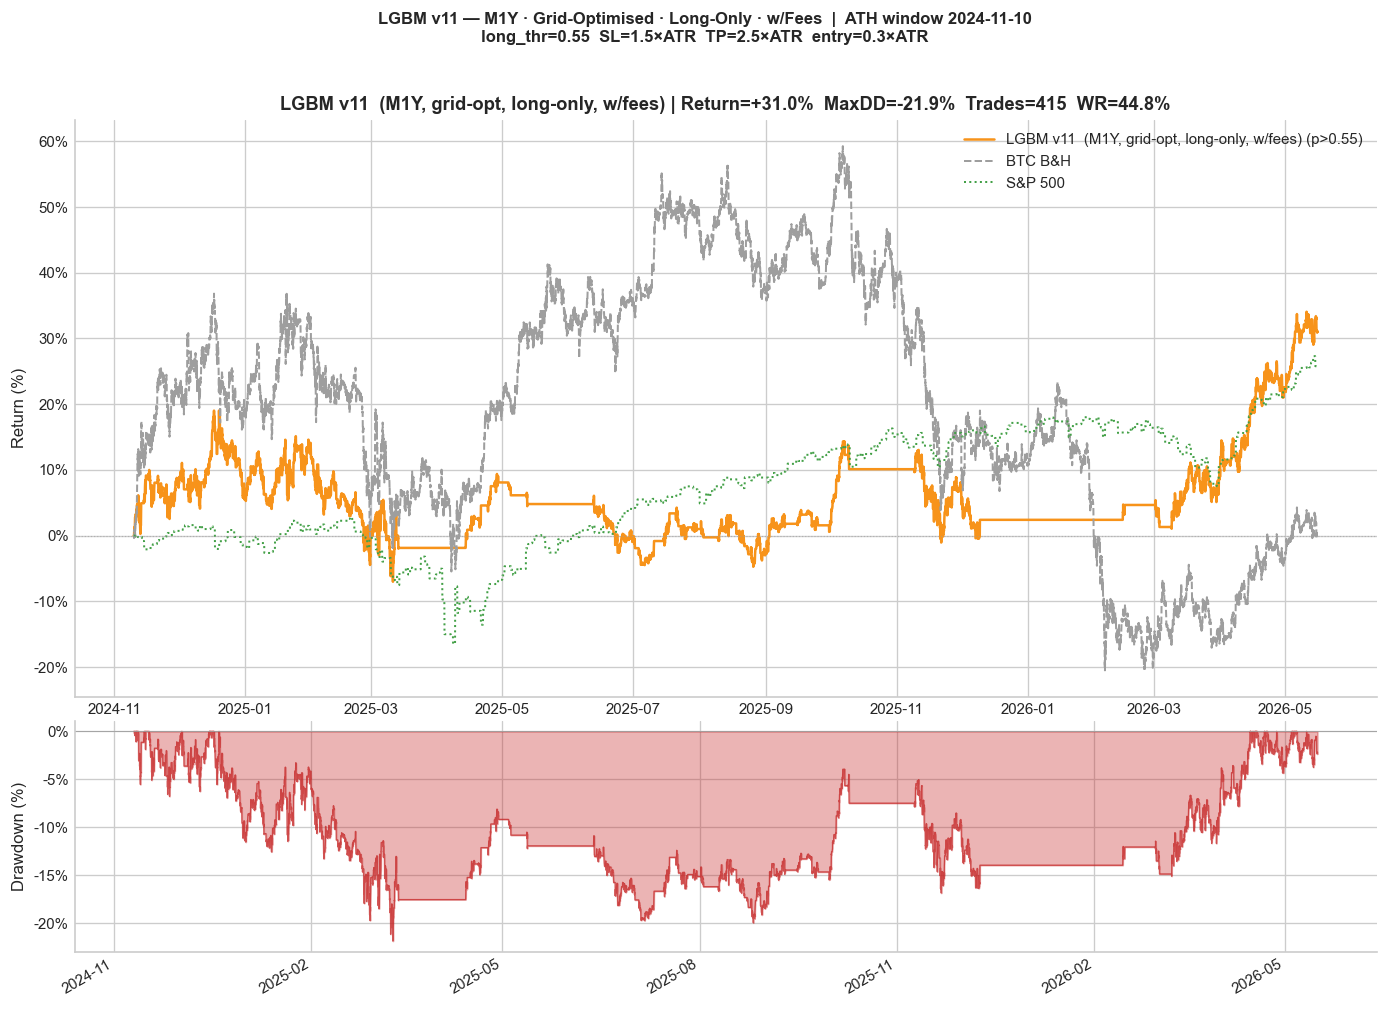

In [12]:
import importlib
import hmats.viz.plots
importlib.reload(hmats.viz.plots)
from hmats.viz.plots import plot_equity_drawdown, save_fig

tdf_ath = tdf_fees.copy() if len(tdf_fees) > 0 else pd.DataFrame()

fig = plot_equity_drawdown(
    oos_index_ath, eq_fees_ath, tdf_ath,
    bh_pct=bh_pct, sp500_pct=sp500_pct,
    label='LGBM v11  (M1Y, grid-opt, long-only, w/fees)',
    threshold=BEST_PARAMS['long_threshold'], color=ACCENT,
)
fig.suptitle(
    f'LGBM v11 — M1Y · Grid-Optimised · Long-Only · w/Fees  |  ATH window {ATH_START.date()}'
    f'\nlong_thr={BEST_PARAMS["long_threshold"]}'
    f'  SL={BEST_PARAMS["sl_atr_mult"]}×ATR  TP={BEST_PARAMS["tp_atr_mult"]}×ATR'
    f'  entry={BEST_PARAMS["entry_atr_mult"]}×ATR',
    fontsize=10, fontweight='bold',
)
save_fig(fig, ARTS_DIR / '01_equity_drawdown.png')
plt.show()

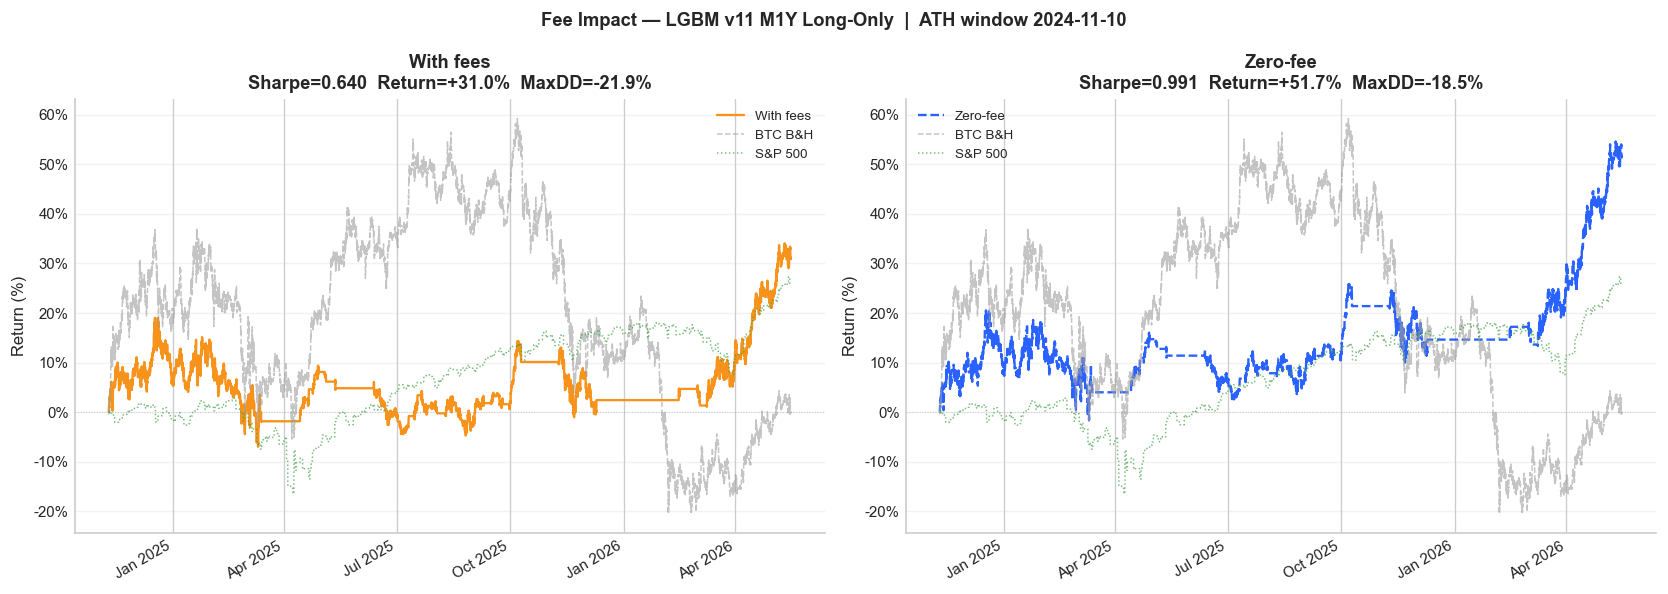

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (lbl, eq, color, ls) in zip(axes, [
    ('With fees',  eq_fees_ath, ACCENT, '-'),
    ('Zero-fee',   eq_0fee_ath, BLUE,   '--'),
]):
    ax.plot(oos_index_ath, (eq-1)*100, color=color, lw=1.4, ls=ls, label=lbl)
    ax.plot(oos_index_ath, bh_pct,     color=GREY,  lw=0.9, ls='--', alpha=0.6, label='BTC B&H')
    if sp500_pct is not None:
        ax.plot(oos_index_ath, sp500_pct.values, color='#43A047', lw=0.9, ls=':', alpha=0.7, label='S&P 500')
    ax.axhline(0, color=GREY, lw=0.6, ls=':', alpha=0.5)
    sh = _sharpe(eq); ret = eq[-1]-1; dd = _maxdd(eq)
    ax.set_title(f'{lbl}\nSharpe={sh:.3f}  Return={ret:+.1%}  MaxDD={dd:.1%}', fontweight='bold')
    ax.set_ylabel('Return (%)'); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0f}%'))
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.25)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle(f'Fee Impact — LGBM v11 M1Y Long-Only  |  ATH window {ATH_START.date()}',
             fontweight='bold', fontsize=11)
fig.tight_layout()
save_fig(fig, ARTS_DIR / '02_fee_comparison.png')
plt.show()

PHASE 4 — MONTHLY RETURN ANALYSIS
Monthly stats (w/ fees, full OOS):
  Positive months : 16 / 29
  Avg monthly ret : +1.95%
  Median monthly  : +1.36%
  Best month      : +16.80%  (Nov 2024)
  Worst month     : -9.78%  (Feb 2025)
  Monthly std dev : 6.44%

open_time
2024-01-31    0.0000
2024-02-29    6.5154
2024-03-31    7.5257
2024-04-30   -9.6007
2024-05-31    0.3299
2024-06-30   -7.5627
2024-07-31    8.5395
2024-08-31   -0.1167
2024-09-30    6.5505
2024-10-31    5.4460
2024-11-30   16.7953
2024-12-31   -2.2711
2025-01-31    5.9267
2025-02-28   -9.7812
2025-03-31   -2.7173
2025-04-30   10.1527
2025-05-31   -3.0429
2025-06-30   -4.9222
2025-07-31    1.3600
2025-08-31   -3.5224
2025-09-30    4.3746
2025-10-31    8.2572
2025-11-30   -3.4010
2025-12-31   -3.7212
2026-01-31    0.0000
2026-02-28    2.2068
2026-03-31    6.9798
2026-04-30    9.0587
2026-05-31    7.2660
Freq: ME


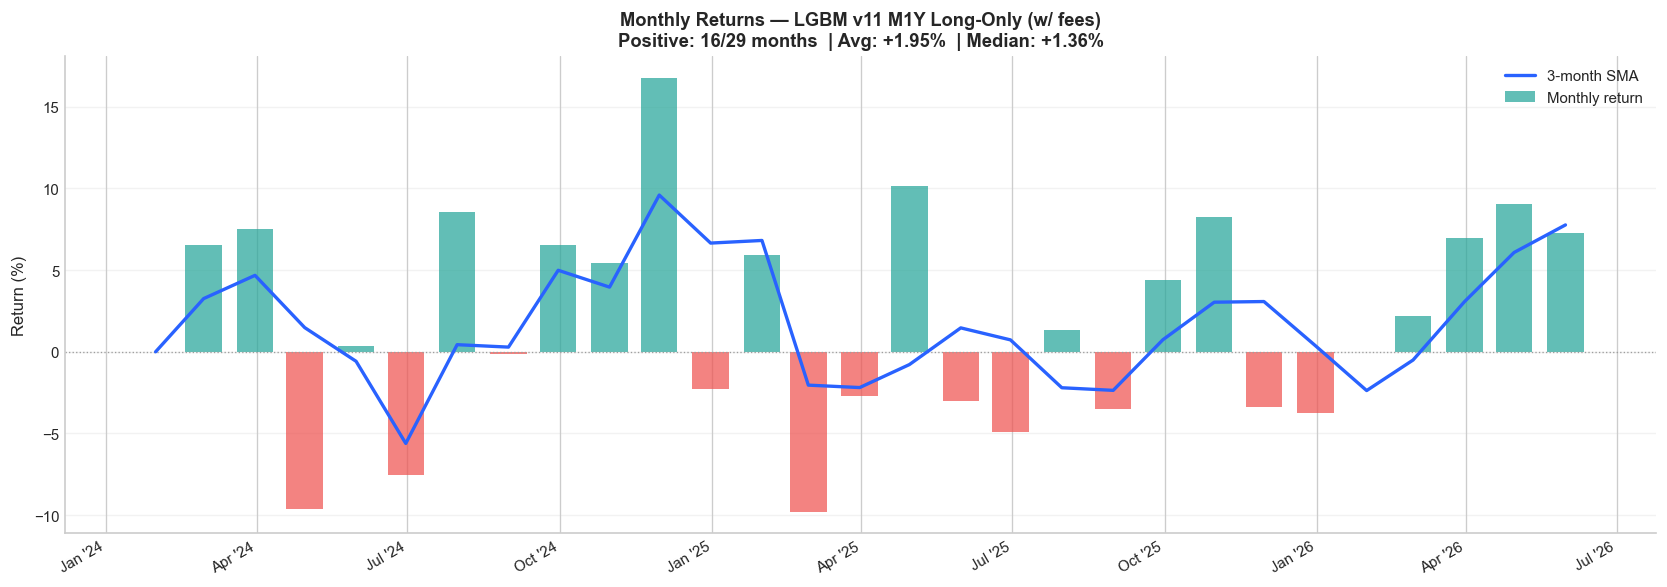

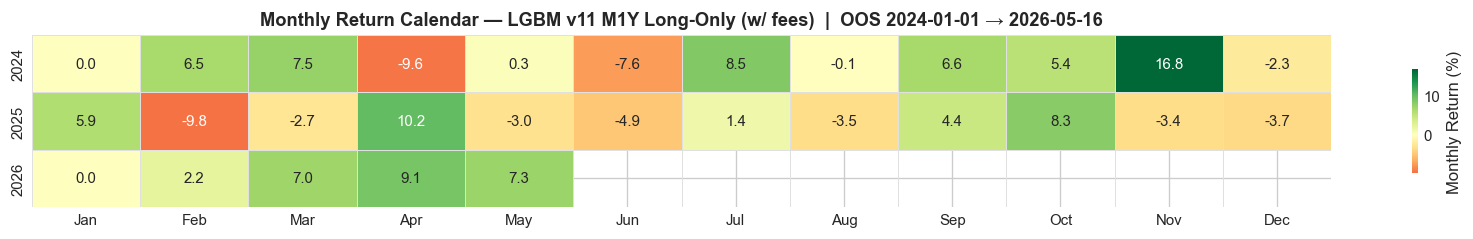

In [14]:
print('='*60)
print('PHASE 4 — MONTHLY RETURN ANALYSIS')
print('='*60)

eq_full_series = pd.Series(eq_fees, index=oos_df.index)
monthly_eq     = eq_full_series.resample('ME').last()
monthly_ret    = monthly_eq.pct_change().fillna(0) * 100
sma3           = monthly_ret.rolling(3, min_periods=1).mean()

print(f'Monthly stats (w/ fees, full OOS):')
print(f'  Positive months : {(monthly_ret>0).sum()} / {len(monthly_ret)}')
print(f'  Avg monthly ret : {monthly_ret.mean():+.2f}%')
print(f'  Median monthly  : {monthly_ret.median():+.2f}%')
print(f'  Best month      : {monthly_ret.max():+.2f}%  ({monthly_ret.idxmax().strftime("%b %Y")})')
print(f'  Worst month     : {monthly_ret.min():+.2f}%  ({monthly_ret.idxmin().strftime("%b %Y")})')
print(f'  Monthly std dev : {monthly_ret.std():.2f}%')
print()
print(monthly_ret.to_string())

# ── Chart A: bar chart + SMA-3 ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
colors = [GREEN if r >= 0 else RED for r in monthly_ret.values]
ax.bar(monthly_ret.index, monthly_ret.values, color=colors, alpha=0.72, width=22, label='Monthly return')
ax.plot(monthly_ret.index, sma3.values, color=BLUE, lw=2.0, label='3-month SMA', zorder=5)
ax.axhline(0, color=GREY, lw=0.8, ls=':')
ax.set_ylabel('Return (%)')
ax.set_title(f'Monthly Returns — LGBM v11 M1Y Long-Only (w/ fees)\n'
             f'Positive: {(monthly_ret>0).sum()}/{len(monthly_ret)} months  '
             f'| Avg: {monthly_ret.mean():+.2f}%  | Median: {monthly_ret.median():+.2f}%',
             fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.25)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
fig.tight_layout()
save_fig(fig, ARTS_DIR / '03_monthly_returns.png')
plt.show()

# ── Chart B: calendar heatmap ─────────────────────────────────────────────────
cal_df = monthly_ret.to_frame('ret').copy()
cal_df['year']  = cal_df.index.year
cal_df['month'] = cal_df.index.month
pivot = cal_df.pivot(index='year', columns='month', values='ret')
pivot.columns = [calendar.month_abbr[m] for m in pivot.columns]

fig2, ax2 = plt.subplots(figsize=(14, max(2, len(pivot)*0.7)))
sns.heatmap(pivot, ax=ax2, cmap='RdYlGn', center=0, annot=True, fmt='.1f',
            linewidths=0.5, linecolor='#e0e0e0',
            cbar_kws={'label': 'Monthly Return (%)', 'shrink': 0.6},
            annot_kws={'size': 9})
ax2.set_title(f'Monthly Return Calendar — LGBM v11 M1Y Long-Only (w/ fees)  |  '
              f'OOS {OOS_START.date()} → {oos_df.index[-1].date()}',
              fontweight='bold')
ax2.set_xlabel(''); ax2.set_ylabel('')
fig2.tight_layout()
save_fig(fig2, ARTS_DIR / '04_monthly_heatmap.png')
plt.show()

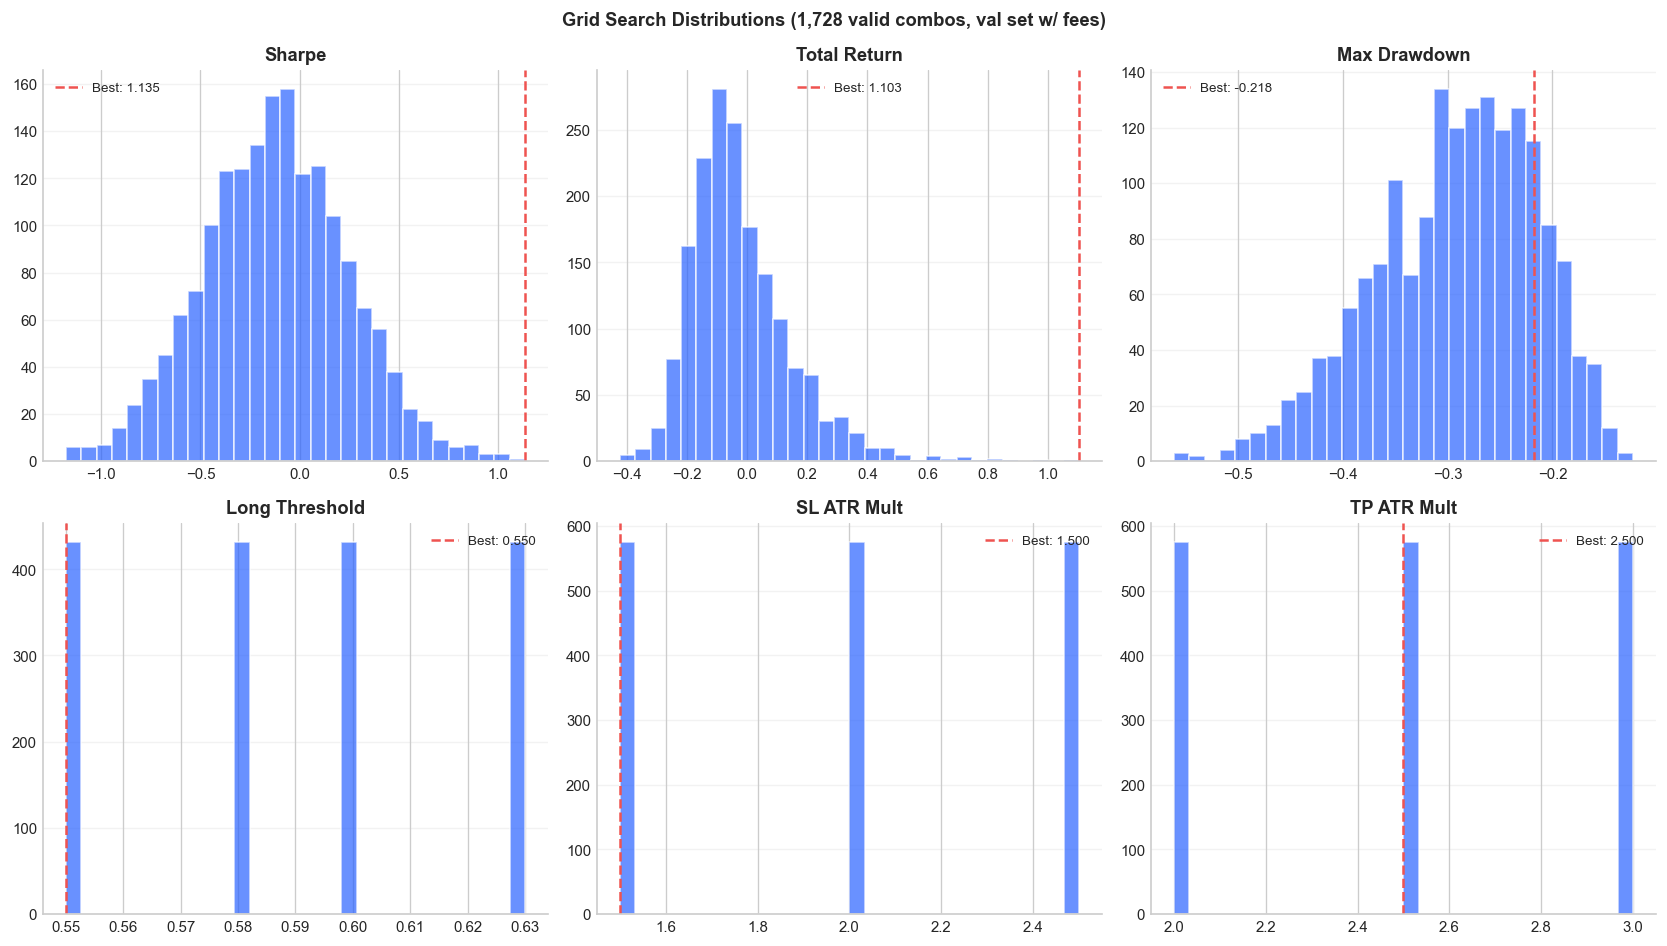

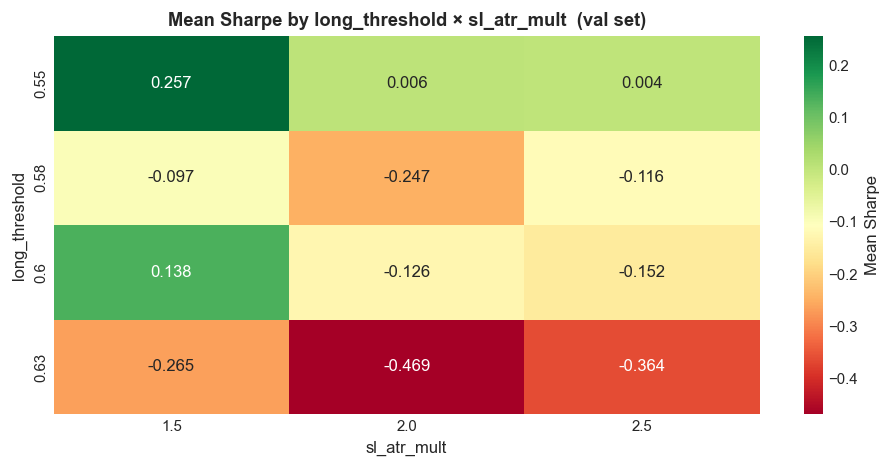

In [15]:
if len(grid_df) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()

    for ax, col in zip(axes, ['sharpe', 'total_ret', 'maxdd',
                               'long_threshold', 'sl_atr_mult', 'tp_atr_mult']):
        data = grid_df[col].dropna()
        label_map = {'total_ret': 'Total Return', 'maxdd': 'Max Drawdown',
                     'sharpe': 'Sharpe', 'long_threshold': 'Long Threshold',
                     'sl_atr_mult': 'SL ATR Mult', 'tp_atr_mult': 'TP ATR Mult'}
        ax.hist(data, bins=30, color=BLUE, alpha=0.7, edgecolor='white')
        best_val = grid_df.iloc[0][col]
        ax.axvline(best_val, color=RED, lw=1.5, ls='--', label=f'Best: {best_val:.3f}')
        ax.set_title(label_map.get(col, col), fontweight='bold')
        ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.25)

    fig.suptitle(f'Grid Search Distributions ({len(grid_df):,} valid combos, val set w/ fees)',
                 fontweight='bold', fontsize=11)
    fig.tight_layout()
    save_fig(fig, ARTS_DIR / '05_grid_distributions.png')
    plt.show()

    # Heatmap: long_threshold × sl_atr_mult (avg Sharpe)
    pivot_gs = grid_df.pivot_table(index='long_threshold', columns='sl_atr_mult',
                                   values='sharpe', aggfunc='mean')
    fig3, ax3 = plt.subplots(figsize=(8, 4))
    sns.heatmap(pivot_gs, ax=ax3, cmap='RdYlGn', annot=True, fmt='.3f',
                cbar_kws={'label': 'Mean Sharpe'})
    ax3.set_title('Mean Sharpe by long_threshold × sl_atr_mult  (val set)',
                  fontweight='bold')
    fig3.tight_layout()
    save_fig(fig3, ARTS_DIR / '06_grid_heatmap.png')
    plt.show()

In [16]:
def _bt_metrics(eq, tdf, label):
    wr = float((tdf['net'] > 0).mean()) if len(tdf) else 0.
    return {
        'label': label,
        'n_trades': len(tdf),
        'win_rate': round(wr, 4),
        'total_ret': round(float(eq[-1] - 1), 4),
        'sharpe': round(_sharpe(eq), 4),
        'maxdd': round(_maxdd(eq), 4),
        'ath_total_ret': round(float(_rebase(eq)[-1] - 1), 4),
        'ath_sharpe': round(_sharpe(_rebase(eq)), 4),
        'ath_maxdd': round(_maxdd(_rebase(eq)), 4),
    }

results = {
    'notebook': '02_lgbm_omni_0fee_v11',
    'version': 'v11',
    'created': pd.Timestamp.now().isoformat(),
    'scheme': 'M1Y (1-year sliding)',
    'direction': 'long-only',
    'grid_type': 'exhaustive',
    'oos_period': f'{OOS_START.date()} → {oos_df.index[-1].date()}',
    'ath_window': f'{ATH_START.date()} → {oos_ath.index[-1].date()}',
    'grid_val_window': f'{GRID_VAL_START.date()} → {GRID_VAL_END.date()}',
    'n_grid_combos': len(_all_combos),
    'n_valid_combos': len(grid_df),
    'oos_auc': round(float(auc_oos), 4),
    'grid_val_auc': round(float(auc_gv), 4),
    'selected_features': SELECTED_FEATURES,
    'best_params': BEST_PARAMS,
    'val_sharpe': round(float(grid_df.iloc[0]['sharpe']), 4),
    'fees': {
        'maker': MAKER_FEE,
        'spot_taker': SPOT_TAKER_FEE,
        'buffer': BUFFER,
    },
    'backtest_wfees': _bt_metrics(eq_fees, tdf_fees, 'w_fees'),
    'backtest_0fee':  _bt_metrics(eq_0fee, tdf_0fee, '0_fee'),
    'monthly_returns': {
        'mean_pct': round(float(monthly_ret.mean()), 3),
        'median_pct': round(float(monthly_ret.median()), 3),
        'std_pct': round(float(monthly_ret.std()), 3),
        'positive_months': int((monthly_ret > 0).sum()),
        'total_months': int(len(monthly_ret)),
        'best_month': {'date': str(monthly_ret.idxmax().date()),
                       'ret': round(float(monthly_ret.max()), 3)},
        'worst_month': {'date': str(monthly_ret.idxmin().date()),
                        'ret': round(float(monthly_ret.min()), 3)},
    }
}

out_path = ARTS_DIR / 'results.json'
with open(out_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f'Saved → {out_path}')
print(json.dumps(results, indent=2)[:1500])

Saved → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/02_lgbm_omni_0fee_v11/results.json
{
  "notebook": "02_lgbm_omni_0fee_v11",
  "version": "v11",
  "created": "2026-05-31T19:07:09.765566",
  "scheme": "M1Y (1-year sliding)",
  "direction": "long-only",
  "grid_type": "exhaustive",
  "oos_period": "2024-01-01 \u2192 2026-05-16",
  "ath_window": "2024-11-10 \u2192 2026-05-16",
  "grid_val_window": "2022-01-01 \u2192 2023-12-31",
  "n_grid_combos": 1728,
  "n_valid_combos": 1728,
  "oos_auc": 0.537,
  "grid_val_auc": 0.5644,
  "selected_features": [
    "close_vs_true_vwap",
    "stoch_k_14",
    "ret_2h",
    "rsi_divergence",
    "close_vs_sma_7",
    "bear_streak",
    "close_vs_s1",
    "macd_hist_5_13",
    "hurst_24h",
    "ad_z_48h",
    "ret_3h"
  ],
  "best_params": {
    "long_threshold": 0.55,
    "entry_atr_mult": 0.3,
    "sl_atr_mult": 1.5,
    "tp_atr_mult": 2.5,
    "min_sl": 0.01,
    "min_hold": 8,
    "max_hold": 48,
    "cooldown": 3
